In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv, jvp, gamma, loggamma
from bessel_zeros import get_bessel_zeros
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

In [ ]:
# ── PARAMETERS ──────────────────────────────────────────────────────────────
T_total = 10.0 #terminal horizon
DIM     = 10 #dimension
N_ZEROS = 500 # number of terms in the Fourier-Bessel series
_eps    = np.finfo(np.float64).eps # small number to avoid division by zero
print(f"Using DIM={DIM}, N_ZEROS={N_ZEROS}")

Using DIM=10, N_ZEROS=500


$$\mathcal{H}_s=1-\frac{1}{2^{\nu-1}\Gamma(\nu+1)}\sum_{n=1}^\infty
\frac{(z_{\nu,n})^{\nu-1}}{J_{\nu+1}(z_{\nu,n})}\,
\exp\!\left(-\tfrac{z_{\nu,n}^2s}{2}\right)$$

In [53]:
def dH_s(dim, S, zeros):
    """
    Same API as your original:
      returns r_star, cdf_r, p_surv0, t_star, raw_t
    with numerically safer internals for large dimensions.
    """
    # ----- setup -----
    nu  = dim/2.0 - 1.0
    x   = np.asarray(zeros, dtype=np.float64)                 # z_{ν,n}
    
    lam = (x*x) / 2.0    # eigenvalues of (1/2)Δ on unit ball = z_{ν,n}^2 / 2


    # ----- stable J_{ν+1}(z_{ν,n}) at roots via derivative identity -----
    # At zeros of J_ν, we have J_{ν+1}(z) = - J'_ν(z) [Watson treatise page 45 (4)]
    Jnu1_roots = -jvp(nu, x, 1)  # derivative w.r.t. argument

    # ----- weights (temporal & spatial) -----
    # coef = 1 / (2^{ν-1} Γ(ν+1))
    coef = 1.0 / (2.0**(nu - 1.0) * gamma(nu + 1.0))

    # A_den = coef * x^{ν-1} / J_{ν+1}(x)
    # Use logs for A_den downstream; still keep a non-log version for shapes/checks if needed
    # log A_den = (nu-1)*log x - (nu-1)*log 2 - log Γ(nu+1) - log J_{ν+1}(x)
    eps = np.finfo(np.float64).tiny
    logA_den = (nu - 1.0) * np.log(np.maximum(x, eps)) \
               - (nu - 1.0) * np.log(2.0) \
               - loggamma(nu + 1.0) \
               - np.log(np.maximum(np.abs(Jnu1_roots), eps))
    # Keep the correct sign for A_den (J_{ν+1} may change sign):
    sign_A_den = np.sign(Jnu1_roots)  # from the -J'_{ν}(x) identity above and negative is the sign of -lam 
    # log with sign: A_den = (coef / J_{ν+1}) * x^{ν-1}; 'coef' part goes into logA_den above implicitly.
    # Since coef > 0, sign is just sign of 1/J_{ν+1} = sign(J_{ν+1})
    # We'll incorporate sign when summing (below we use pure log-sum-exp on magnitudes, so A_den must be ≥0).
    # For time/survival series the standard closed form yields positive terms, so force nonnegative by magnitude:
    # (If your zeros/ordering create alternating signs numerically, taking abs here is the safe practical choice.)
    logA_den_mag = logA_den  # magnitude in log-domain (we treat terms as positive in the survival/time sums)


    # ----- exponentials for full nondimensional step S -----
    expS = np.exp(-lam * S)  # e^{- (z^2/2) S }

    # ----- survival probability p_surv0 with log-sum-exp -----
    # p_surv0 = Σ_n A_den * e^{-lam*S}
    # => log terms = logA_den_mag - lam*S
    log_terms_surv = logA_den_mag - lam * S 
    dlog_terms_surv = logA_den_mag - lam * S + np.log(lam)
    m = np.max(log_terms_surv)
    oneminusH = float(np.exp(m) * np.sum(sign_A_den*np.exp(log_terms_surv - m))) #Here is where sign_A_den is multiplied back in.
    dH = float(np.exp(m) * np.sum(sign_A_den*np.exp(dlog_terms_surv - m)))
    # Guard against complete underflow
    if not np.isfinite(oneminusH) or oneminusH < 0.0:
        oneminusH = 0.0
    if oneminusH > 1.0:
        oneminusH = 1.0
    if not np.isfinite(dH) or dH <= 0.0:
        dH = 0.0    
    return 1-oneminusH,dH

In [ ]:
dims = [2, 10, 50, 100]
H_s = {}
eps = np.finfo(np.float64).tiny
S = np.arange(0.0045, 1.5, 0.00025)
for i,d in enumerate(dims):
    # 1) Bessel zeros
    print("Computing Bessel function zeros…")
    zeros = get_bessel_zeros(d, N_ZEROS)
    print(f" Retrieved {len(zeros)} zeros for ν={d/2 -1}")
    print(f"Computing H_s for d={d}…")
    Z = []
    dZ = []
    for s in S:
        tmp = dH_s(d, s, zeros)
        Z.append(tmp[0])
        dZ.append(tmp[1])
    H_s[d] = np.array([S, Z, dZ])  

Computing Bessel function zeros…
 Retrieved 500 zeros for ν=0.0
Computing H_s for d=2…
Computing Bessel function zeros…
 Retrieved 500 zeros for ν=4.0
Computing H_s for d=10…
Computing Bessel function zeros…
 Retrieved 500 zeros for ν=24.0
Computing H_s for d=50…
Computing Bessel function zeros…
 Retrieved 500 zeros for ν=49.0
Computing H_s for d=100…


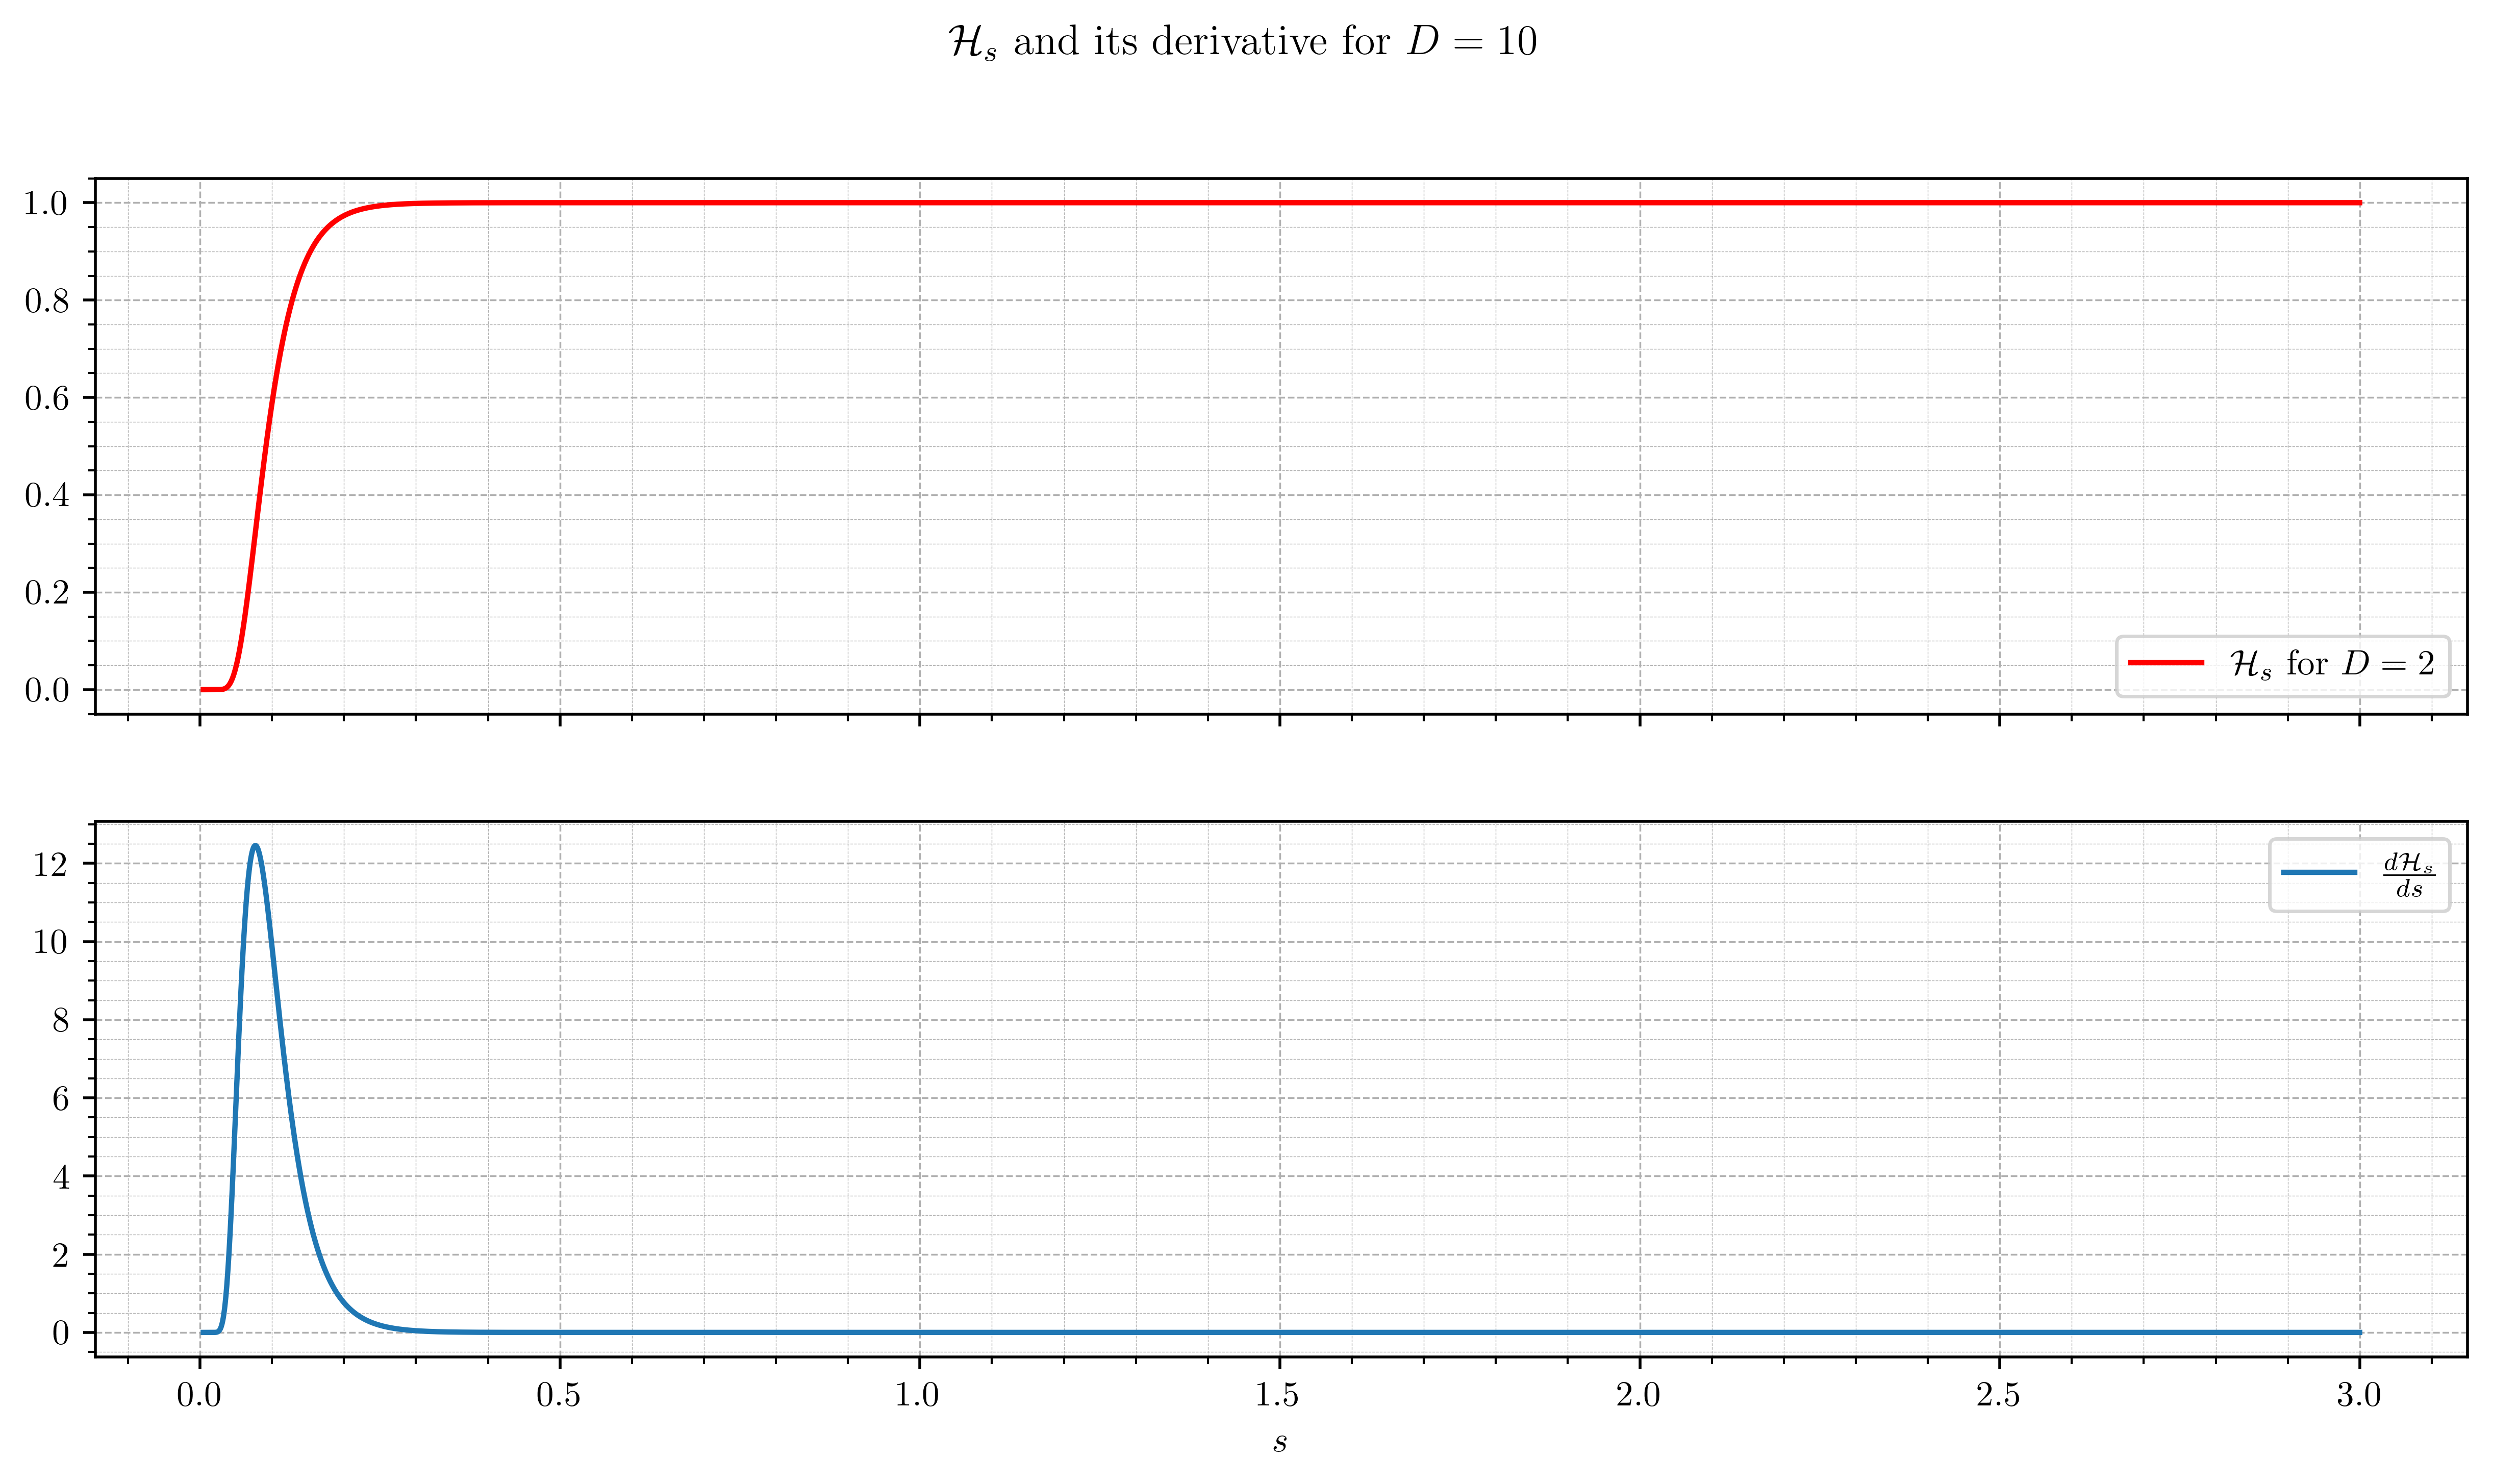

In [75]:

fig,ax = plt.subplots(2,1,figsize=(12,6),dpi=500,sharex=True);
# for i,d in enumerate(dims):
#     ax[0].plot(H_s[d][0][:,0], H_s[d][0][:,1], marker=marks[i], linestyle=linestyles[i], color=colors[i], label=r'$\mathcal{{H}}_s$ for d={}'.format(d));
#     ax[1].plot(H_s[d][1][:,0], H_s[d][1][:,1], marker=marks[i], linestyle=linestyles[i], color=colors[i], label=r'$\frac{d\mathcal{{H}}_s}{ds}$ for d={}'.format(d));
ax[0].plot(H_s[10][0,:],H_s[10][1,:],label=r'$\mathcal{H}_s$ for $D=2$',color='r');
ax[0].grid(visible=True, which='major', axis='both', linestyle='--', linewidth=0.5);
ax[0].minorticks_on()
ax[0].grid(visible=True, which='minor', axis='both', linestyle='--', linewidth=0.2);
ax[1].plot(H_s[10][0,:],H_s[10][2,:],label=r'$\frac{d\mathcal{H}_s}{ds}$');
ax[1].grid(visible=True, which='major', axis='both', linestyle='--', linewidth=0.5);
ax[1].minorticks_on()
ax[1].grid(visible=True, which='minor', axis='both', linestyle='--', linewidth=0.2);
ax[1].set_xlabel(r'$s$')
fig.suptitle(r"$\mathcal{{H}}_s$ and its derivative for $D={}$".format(10));
ax[0].legend();
ax[1].legend();
plt.show();

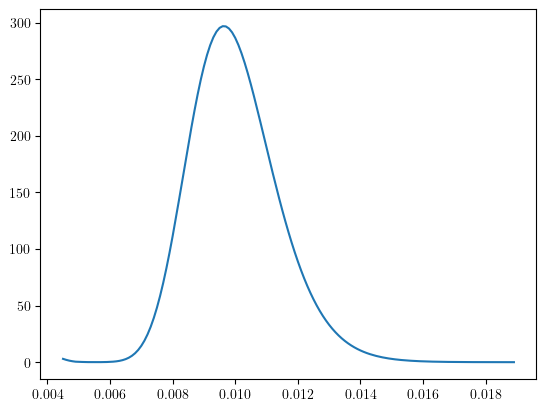

In [76]:
range = H_s[100][2,:]>1e-2
s_range = H_s[100][0,:][range]
v_range = H_s[100][2,:][range]
plt.plot(s_range, v_range);

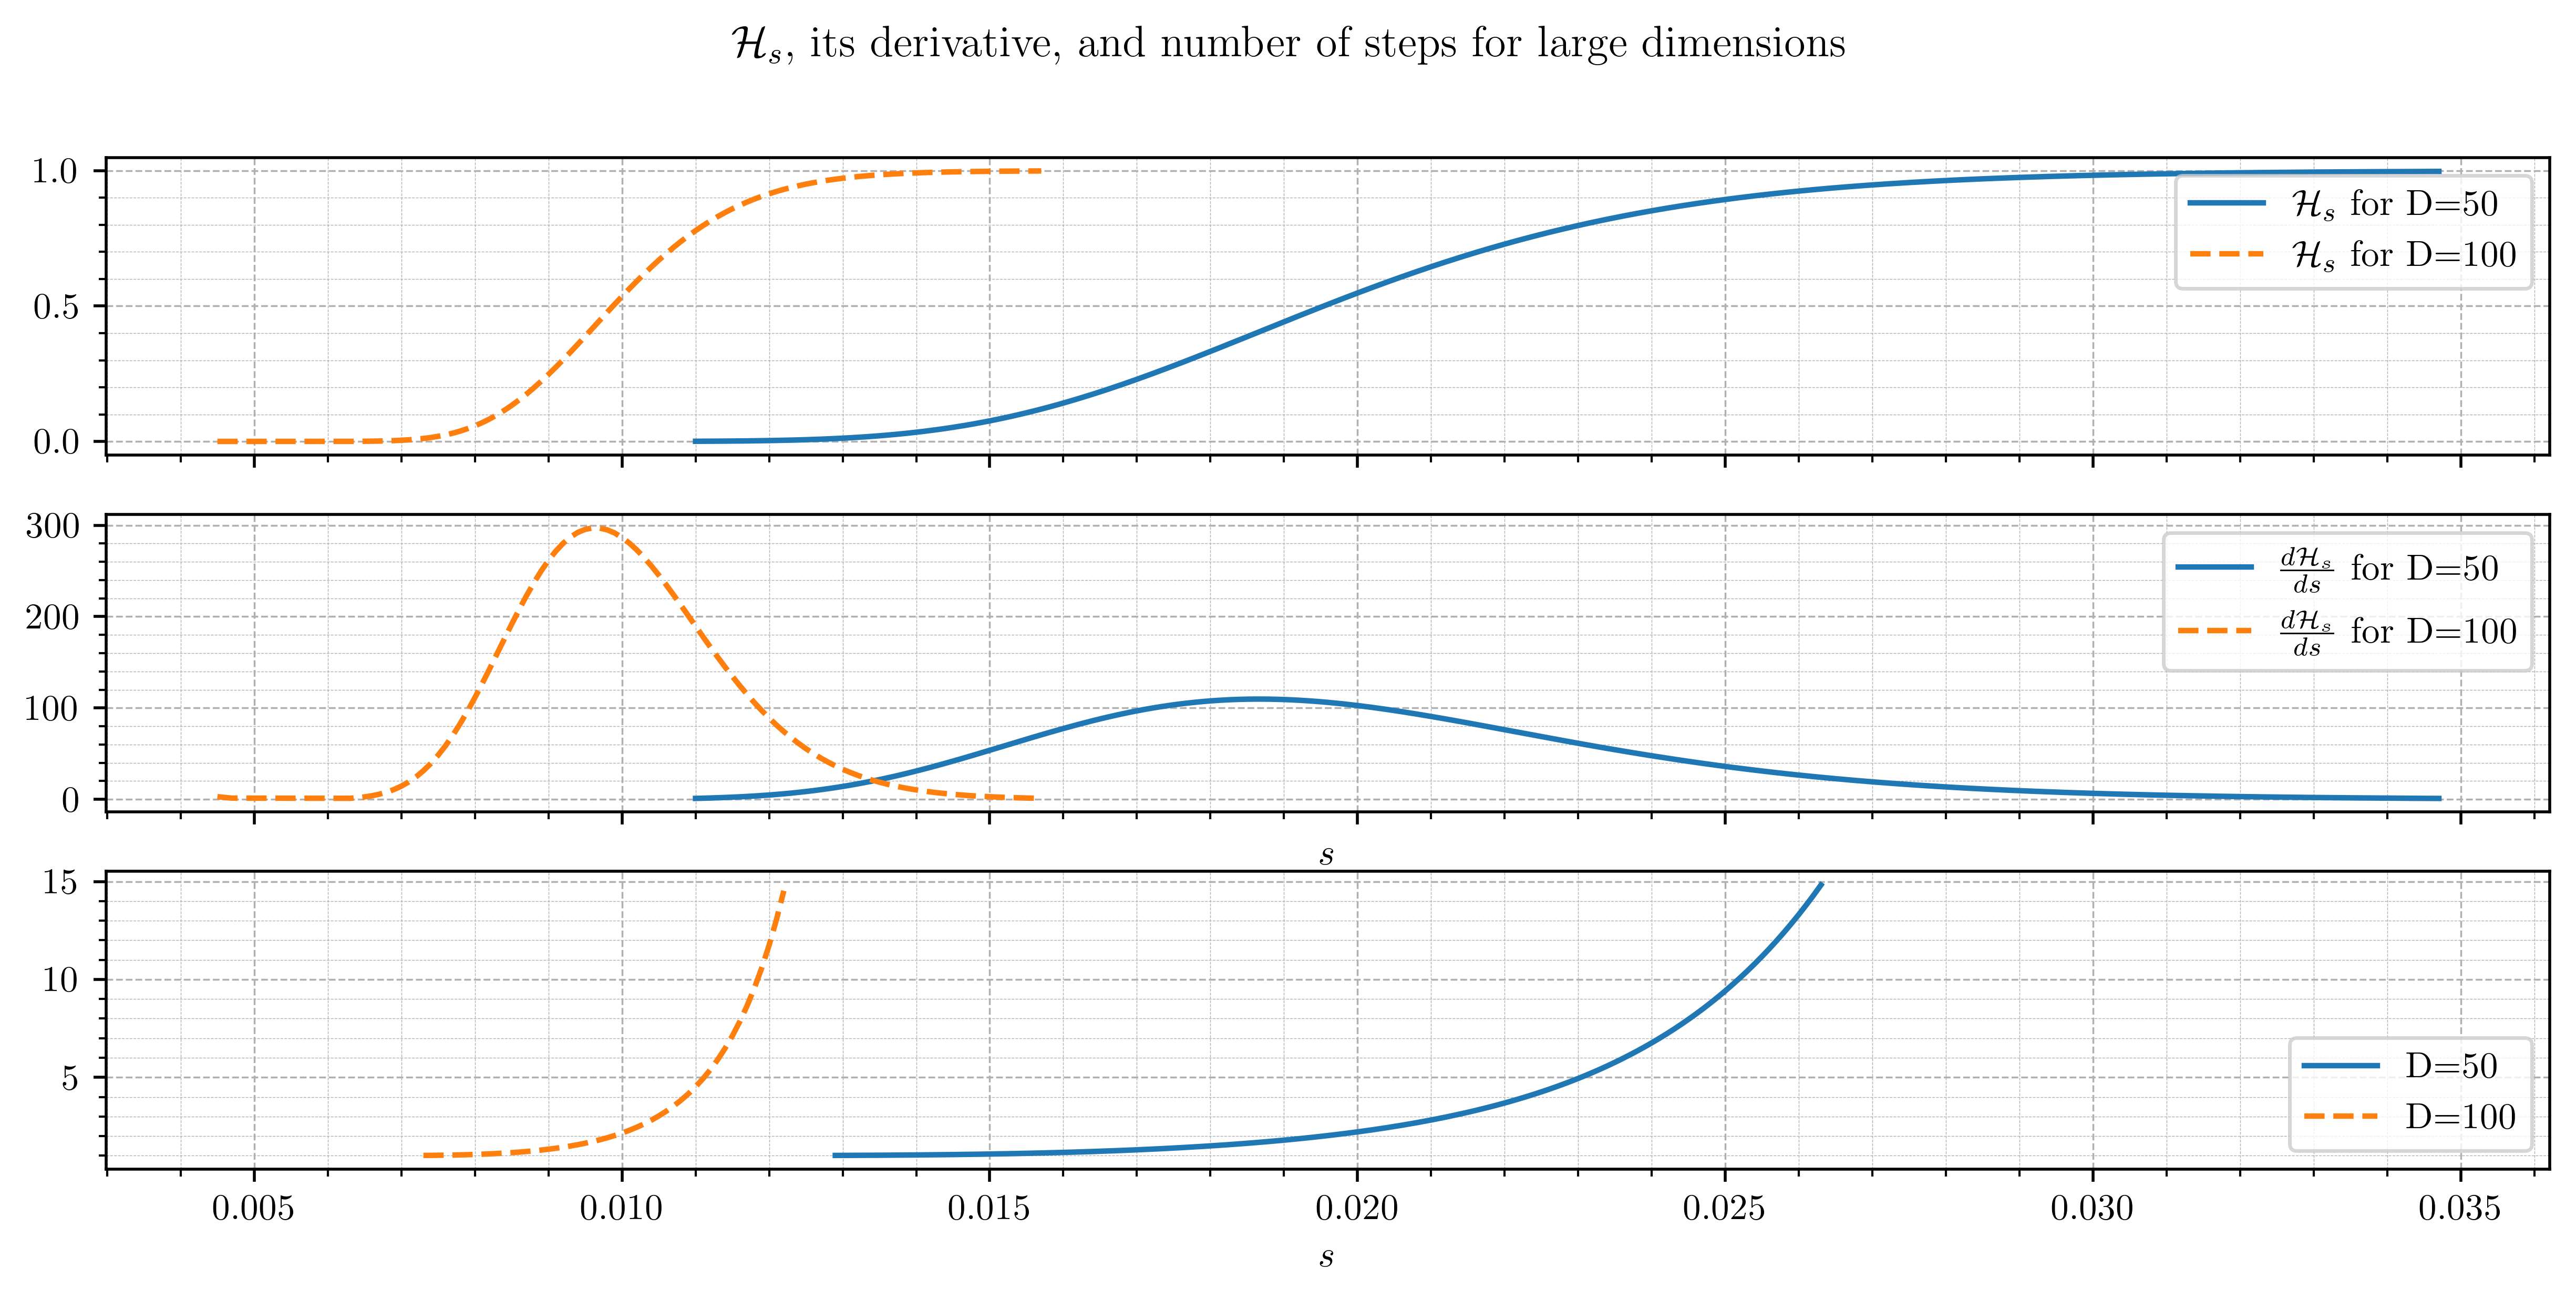

In [96]:
# ── PLOTTING ───────────────────────────────────────────────────────────────
# marks = ['o', 's', 'D', '^']
linestyles = ['-', '--', '-.', ':']
colors = ['C0', 'C1', 'C2', 'C3']
fig, ax = plt.subplots(3, 1, figsize=(12, 5),sharex=True, dpi=500)
for i,d in enumerate([50,100]):
    range = H_s[d][2,:]>1e0
    ax[0].plot(H_s[d][0,:][range],H_s[d][1,:][range], linestyle=linestyles[i], color=colors[i], label=r'$\mathcal{{H}}_s$ for D={}'.format(d));
# plt.plot(H_s[DIM][0,:],H_s[DIM][1,:],label=r'$\mathcal{H}_s$',color='r');
ax[0].grid(visible=True, which='major', axis='both', linestyle='--', linewidth=0.5);
ax[0].minorticks_on()
ax[0].grid(visible=True, which='minor', axis='both', linestyle='--', linewidth=0.2);
ax[0].legend();
for i,d in enumerate([50,100]):
    range = H_s[d][2,:]>1e0
    ax[1].plot(H_s[d][0,:][range],H_s[d][2,:][range], linestyle=linestyles[i], color=colors[i], label=r'$\frac{{d\mathcal{{H}}_s}}{{ds}}$ for D={}'.format(d));
ax[1].grid(visible=True, which='major', axis='both', linestyle='--', linewidth=0.5);
ax[1].minorticks_on()
ax[1].grid(visible=True, which='minor', axis='both', linestyle='--', linewidth=0.2);
ax[1].set_xlabel(r'$s$')
plt.suptitle(r"$\mathcal{{H}}_s$, its derivative, and number of steps for large dimensions");
ax[1].legend();
for i,d in enumerate([50,100]):
    range1 = H_s[d][2,:]>1e-3
    range2 = H_s[d][1,:]<1 - 1/15
    range3 = H_s[d][1,:]> 0.01/1.01
    range = range1 * range2 *range3
# s_min,s_max = s_range.min(), s_range.max()
    ax[2].plot(H_s[d][0,:][range],1/(1-H_s[d][1,:][range]), linestyle=linestyles[i], color=colors[i], label=r'D={}'.format(d));
# plt.plot(H_s[DIM][0,:],H_s[DIM][1,:],label=r'$\mathcal{H}_s$',color='r');
ax[2].grid(visible=True, which='major', axis='both', linestyle='--', linewidth=0.5);
ax[2].minorticks_on()
ax[2].grid(visible=True, which='minor', axis='both', linestyle='--', linewidth=0.2);
ax[2].legend(loc='lower right');
ax[2].set_xlabel(r'$s$')

plt.savefig("H_s_large_dims.pdf", bbox_inches='tight', dpi=500);

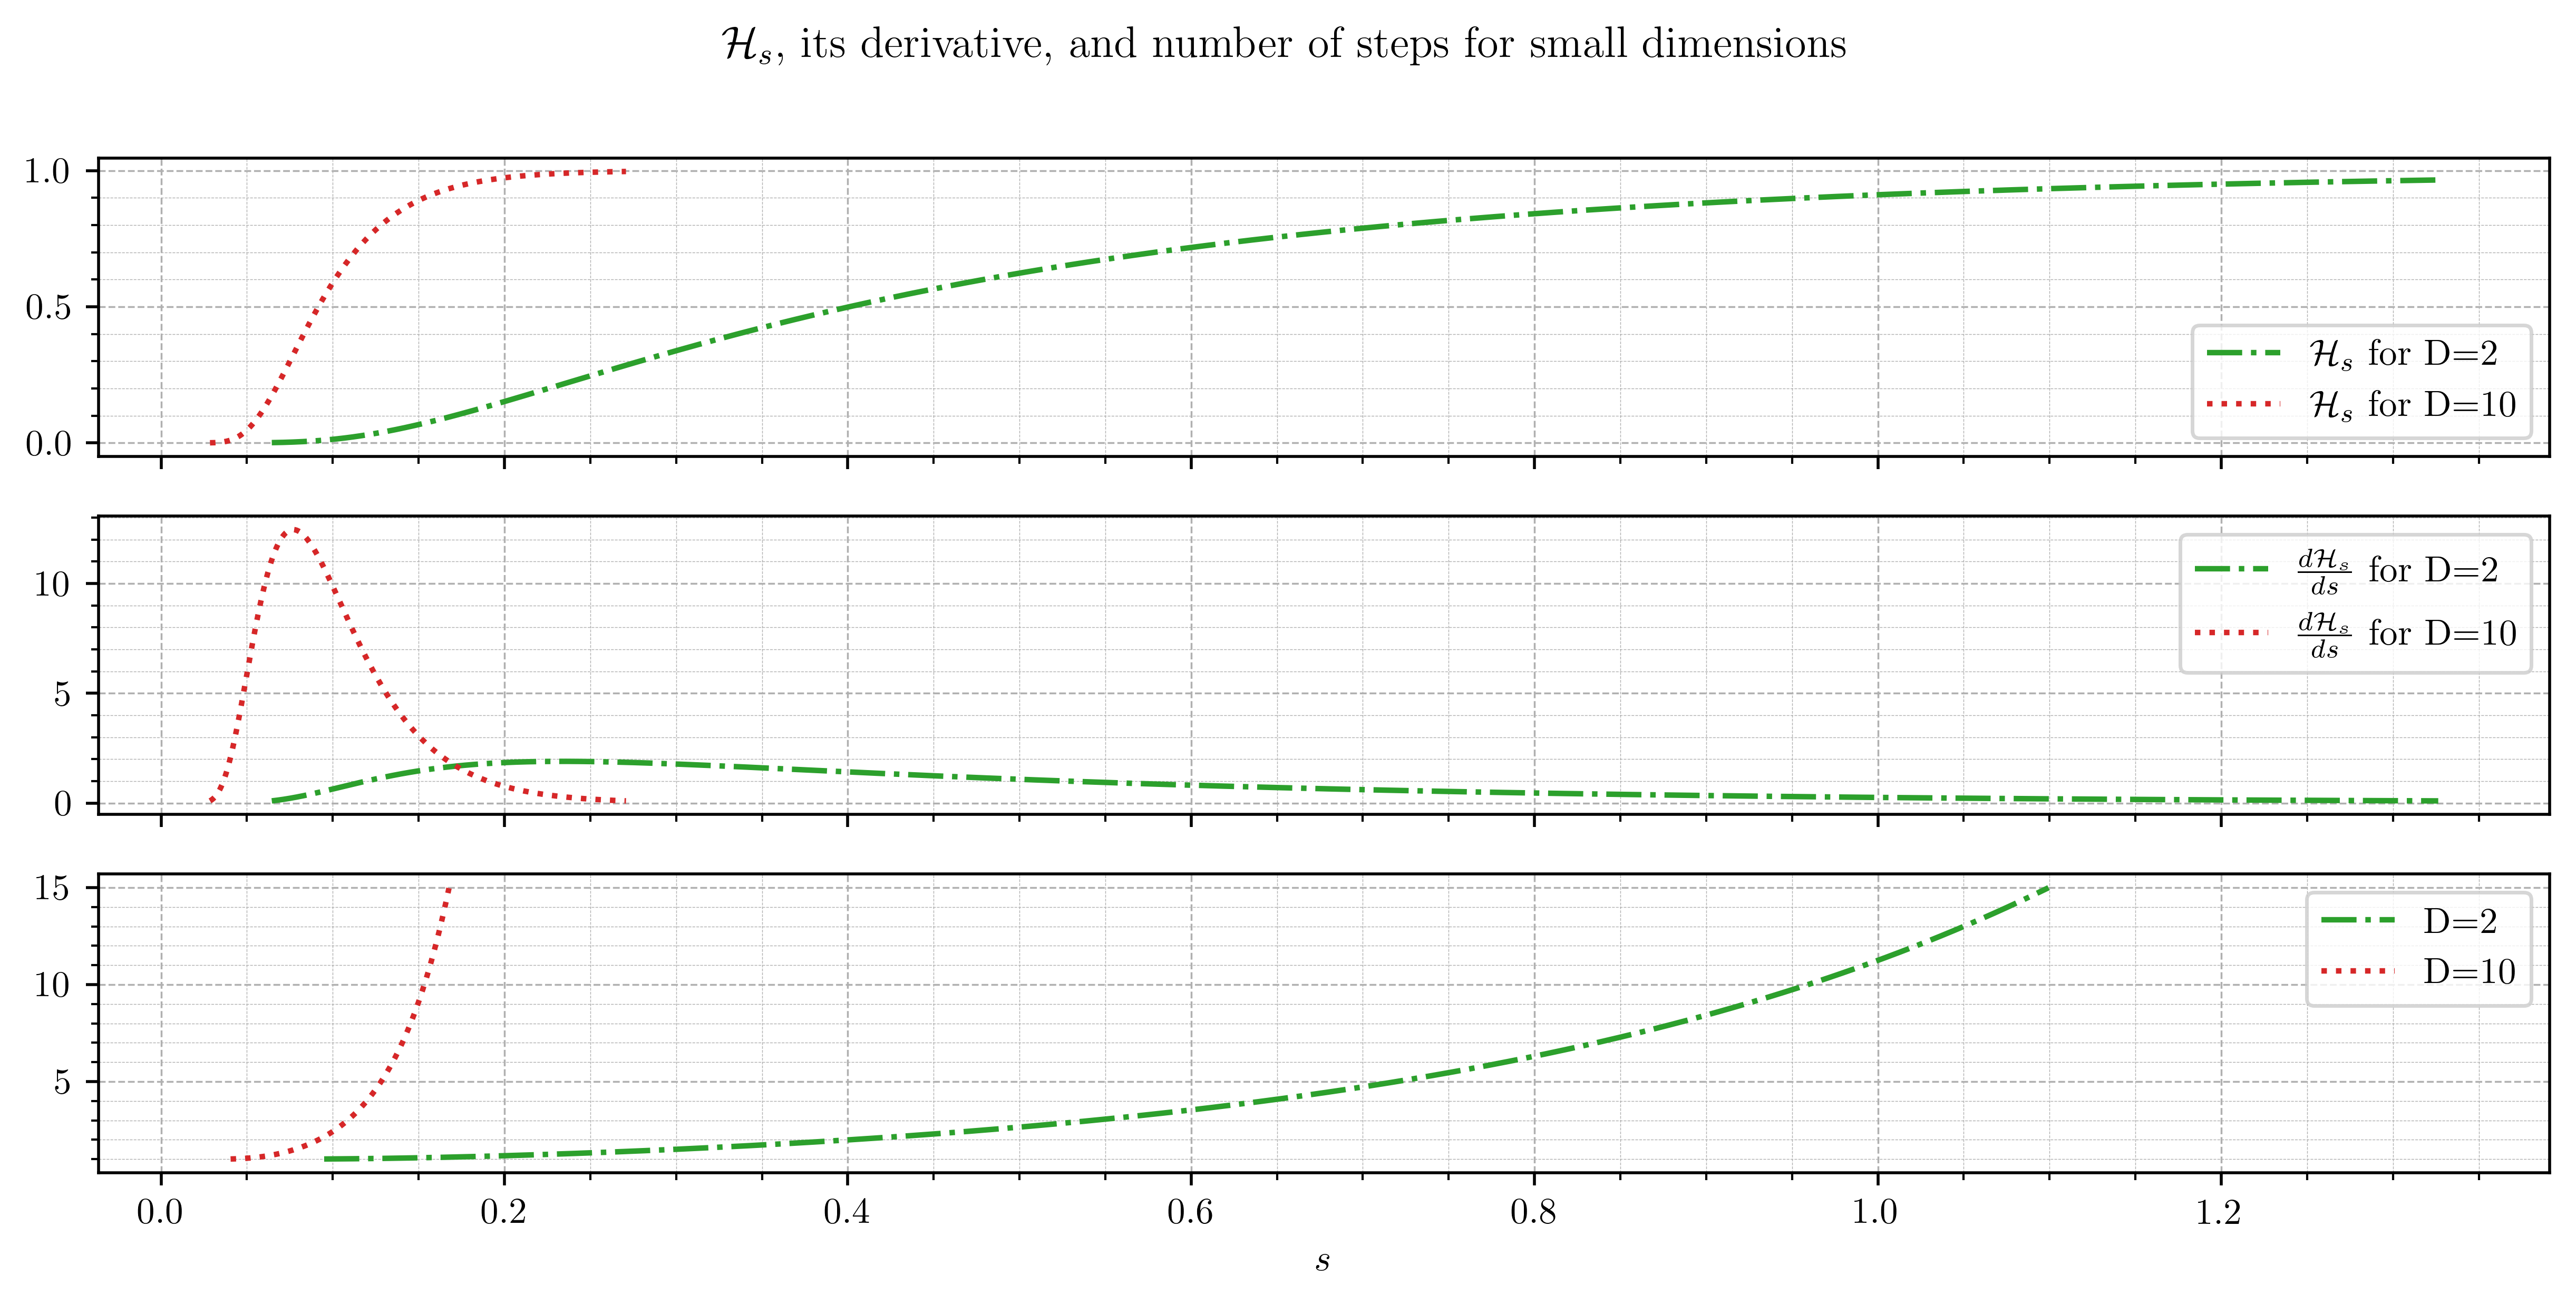

In [100]:
# ── PLOTTING ───────────────────────────────────────────────────────────────
# marks = ['o', 's', 'D', '^']
linestyles = [ '-.', ':']
colors = ['C2', 'C3']
fig, ax = plt.subplots(3, 1, figsize=(12, 5),sharex=True, dpi=500)
for i,d in enumerate([2,10]):
    range = H_s[d][2,:]>1e-1
# s_min,s_max = s_range.min(), s_range.max()
    ax[0].plot(H_s[d][0,:][range],H_s[d][1,:][range], linestyle=linestyles[i], color=colors[i], label=r'$\mathcal{{H}}_s$ for D={}'.format(d));
# plt.plot(H_s[DIM][0,:],H_s[DIM][1,:],label=r'$\mathcal{H}_s$',color='r');
ax[0].grid(visible=True, which='major', axis='both', linestyle='--', linewidth=0.5);
ax[0].minorticks_on()
ax[0].grid(visible=True, which='minor', axis='both', linestyle='--', linewidth=0.2);
ax[0].legend();
for i,d in enumerate([2,10]):
    range = H_s[d][2,:]>1e-1
    ax[1].plot(H_s[d][0,:][range],H_s[d][2,:][range], linestyle=linestyles[i], color=colors[i], label=r'$\frac{{d\mathcal{{H}}_s}}{{ds}}$ for D={}'.format(d));
# plt.plot(H_s[DIM][0,:],H_s[DIM][2,:],label=r'$\frac{d\mathcal{H}_s}{ds}$');
ax[1].grid(visible=True, which='major', axis='both', linestyle='--', linewidth=0.5);
ax[1].minorticks_on()
ax[1].grid(visible=True, which='minor', axis='both', linestyle='--', linewidth=0.2);
plt.suptitle(r"$\mathcal{{H}}_s$, its derivative, and number of steps for small dimensions");
ax[1].legend();
for i,d in enumerate([2,10]):
    range1 = H_s[d][2,:]>1e-1
    range2 = H_s[d][1,:]<1 - 1/15
    range3 = H_s[d][1,:]> 0.01/1.01
    range = range1 * range2 *range3
# s_min,s_max = s_range.min(), s_range.max()
    ax[2].plot(H_s[d][0,:][range],1/(1-H_s[d][1,:][range]), linestyle=linestyles[i], color=colors[i], label=r'D={}'.format(d));
# plt.plot(H_s[DIM][0,:],H_s[DIM][1,:],label=r'$\mathcal{H}_s$',color='r');
ax[2].grid(visible=True, which='major', axis='both', linestyle='--', linewidth=0.5);
ax[2].minorticks_on()
ax[2].grid(visible=True, which='minor', axis='both', linestyle='--', linewidth=0.2);
ax[2].set_xlabel(r'$s$')
ax[2].legend();
plt.savefig("H_s_small_dims.pdf", bbox_inches='tight', dpi=500);

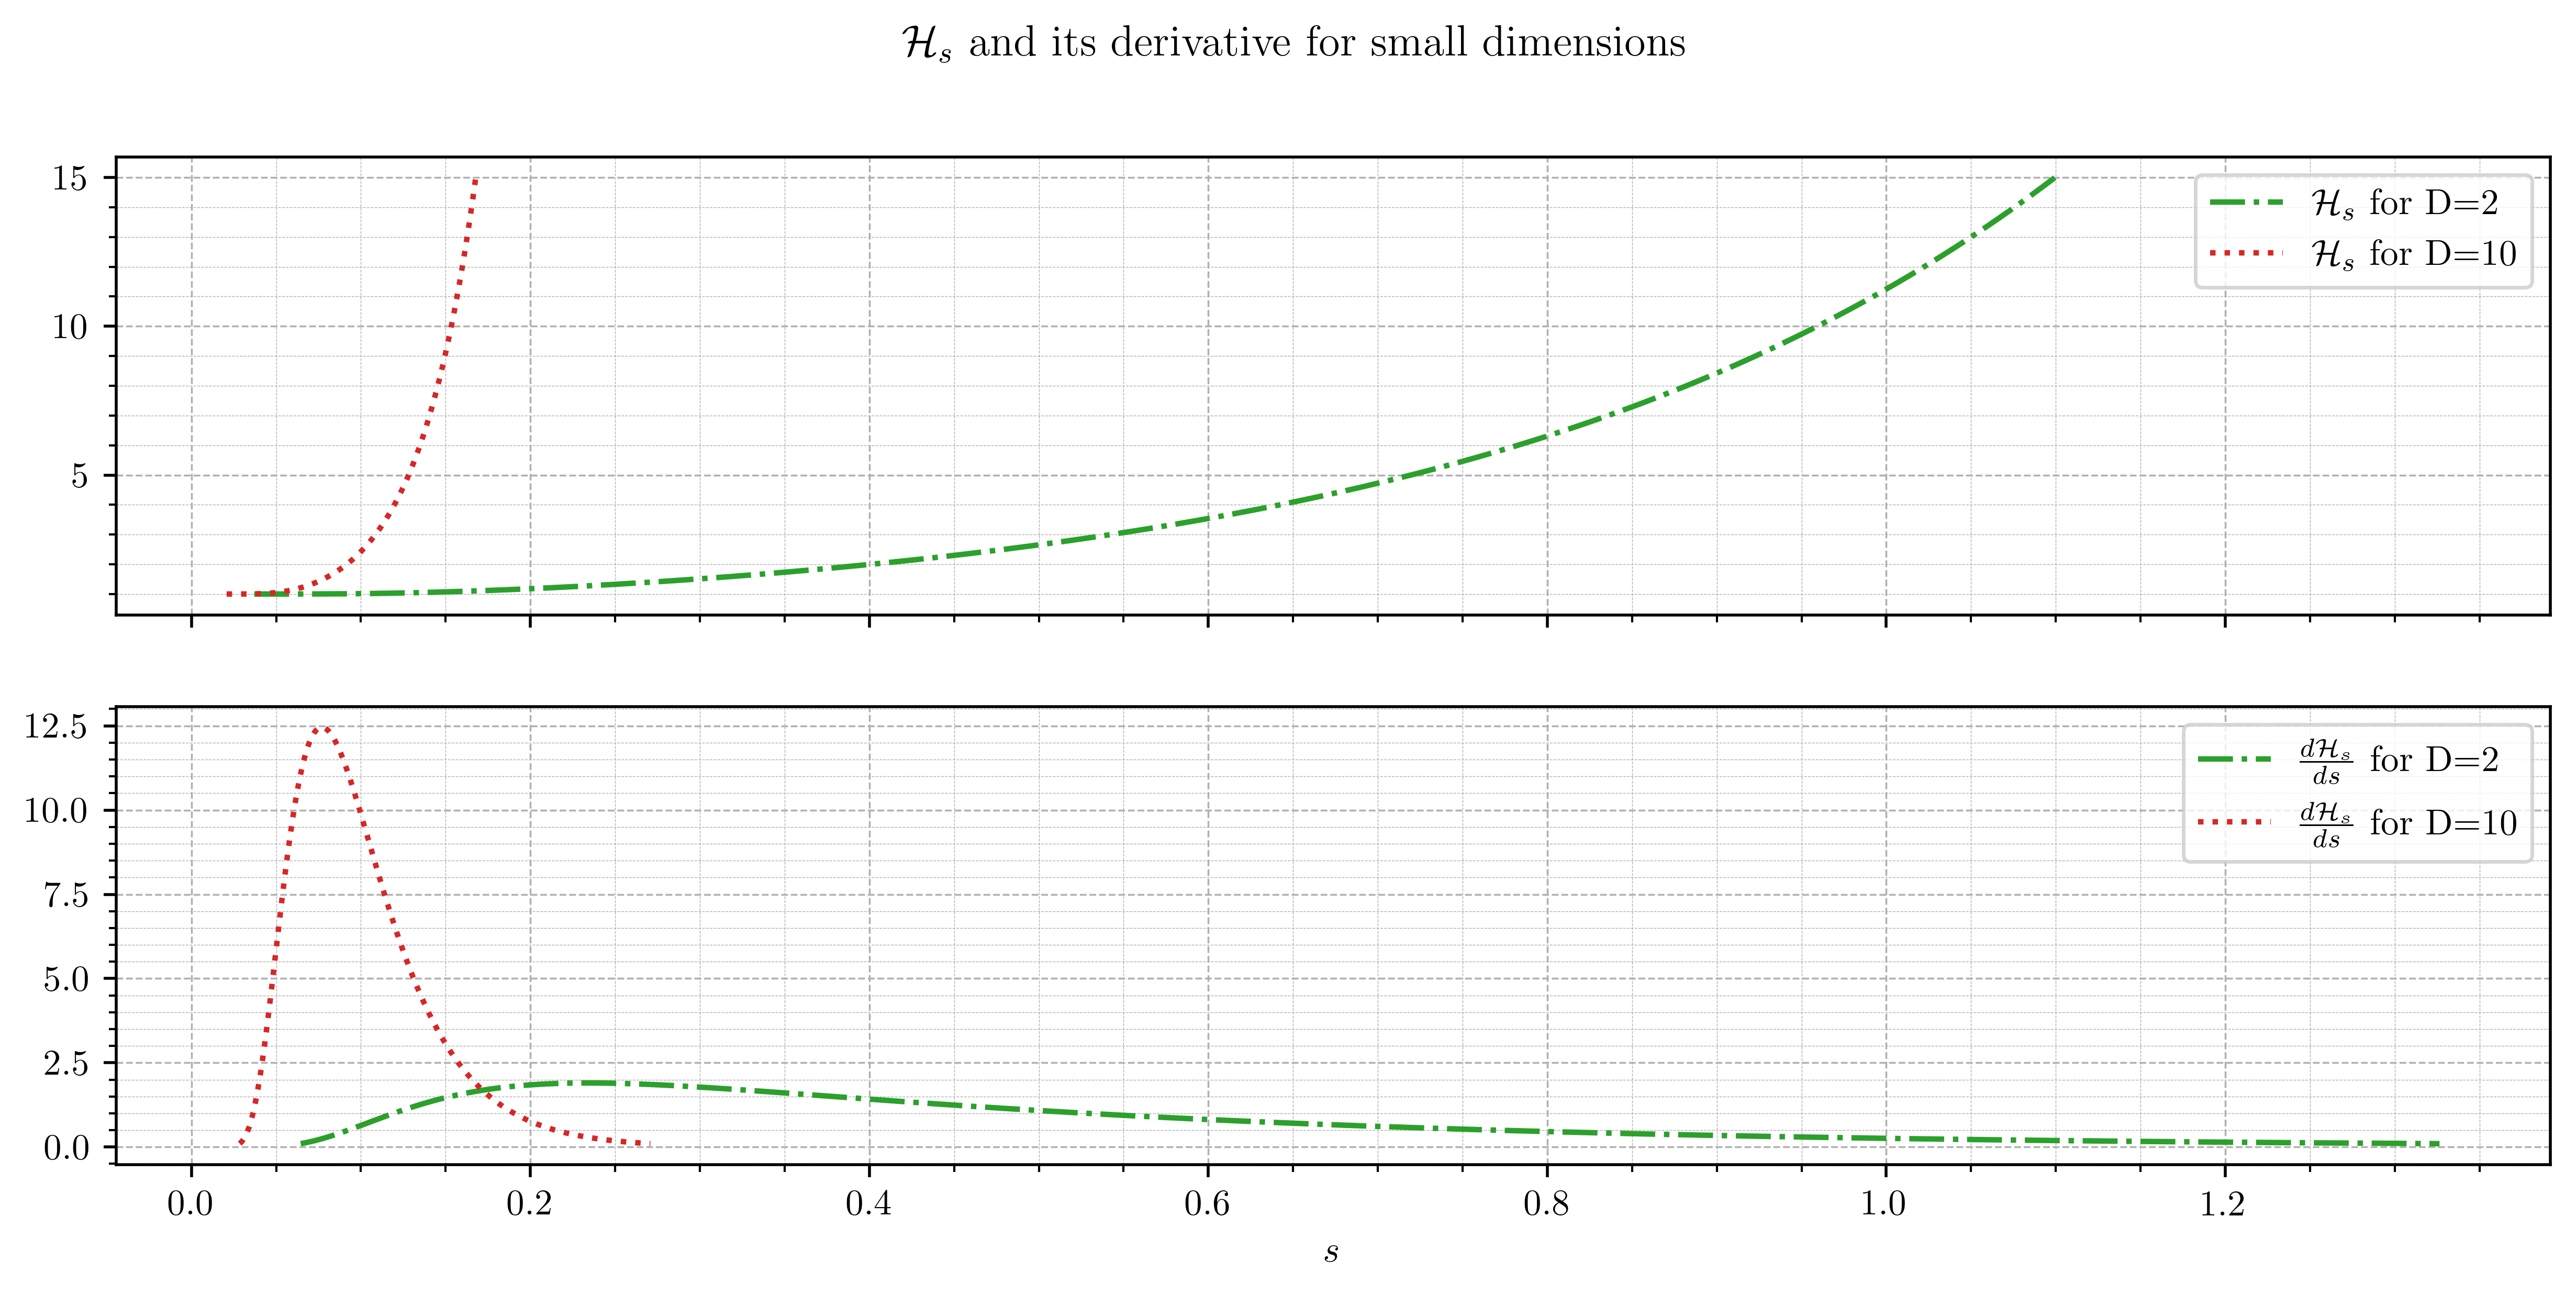

In [ ]:
# ── PLOTTING ───────────────────────────────────────────────────────────────
# marks = ['o', 's', 'D', '^']
linestyles = [ '-.', ':']
colors = ['C2', 'C3']
fig, ax = plt.subplots(2, 1, figsize=(12, 5),sharex=True, dpi=500)
for i,d in enumerate([2,10]):
    range1 = H_s[d][2,:]>1e-3
    range2 = H_s[d][1,:]<1 - 1/15
    range = range1 * range2
# s_min,s_max = s_range.min(), s_range.max()
    ax[0].plot(H_s[d][0,:][range],1/(1-H_s[d][1,:][range]), linestyle=linestyles[i], color=colors[i], label=r'D={}'.format(d));
# plt.plot(H_s[DIM][0,:],H_s[DIM][1,:],label=r'$\mathcal{H}_s$',color='r');
ax[0].grid(visible=True, which='major', axis='both', linestyle='--', linewidth=0.5);
ax[0].minorticks_on()
ax[0].grid(visible=True, which='minor', axis='both', linestyle='--', linewidth=0.2);
ax[0].legend();
for i,d in enumerate([2,10]):
    range = H_s[d][2,:]>1e-1
    ax[1].plot(H_s[d][0,:][range],H_s[d][2,:][range], linestyle=linestyles[i], color=colors[i], label=r'$\frac{{d\mathcal{{H}}_s}}{{ds}}$ for D={}'.format(d));
# plt.plot(H_s[DIM][0,:],H_s[DIM][2,:],label=r'$\frac{d\mathcal{H}_s}{ds}$');
ax[1].grid(visible=True, which='major', axis='both', linestyle='--', linewidth=0.5);
ax[1].minorticks_on()
ax[1].grid(visible=True, which='minor', axis='both', linestyle='--', linewidth=0.2);
ax[1].set_xlabel(r'$s$')
plt.suptitle(r"$\mathcal{{H}}_s$ and its derivative for small dimensions");
ax[1].legend();
plt.savefig("H_s_small_dims.pdf", bbox_inches='tight', dpi=500);